# Set up

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[1]))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod
from dataclasses import dataclass
import scipy

In [3]:
# from Part2_Classification.utils import *

## Configuaration

In [4]:
SEED = 42
LEARNING_RATE = 0.01
MAX_ITER = 10000

In [5]:
def set_seed(seed: int) -> None:
  np.random.seed(seed)

set_seed(SEED)

# Process data

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# 1. LOAD DATA
file = 'Dry_Bean_Dataset.xlsx'
try:
    df = pd.read_excel(file) # Usually the first sheet is default
except Exception as e:
    print(f"Error loading file: {e}")

# 2. SEPARATE TARGET FROM FEATURES IMMEDIATELY
# This prevents the 'Class' column from being treated as a feature during scaling
X = df.drop('Class', axis=1)
y = df['Class']

# 3. SPLIT DATA FIRST (To prevent Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. IDENTIFY COLUMN TYPES ON X_TRAIN
non_numeric_cols = X_train.select_dtypes(exclude=[np.number]).columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

# 5. IMPUTATION (Fit on Train, Transform on both)
# Numeric Imputer
num_imputer = SimpleImputer(strategy='mean')
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

# Categorical Imputer (If there are any non-numeric features)
if not non_numeric_cols.empty:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train[non_numeric_cols] = cat_imputer.fit_transform(X_train[non_numeric_cols])
    X_test[non_numeric_cols] = cat_imputer.transform(X_test[non_numeric_cols])

# 6. ENCODE FEATURES (If any)
label_encoders = {}
for col in non_numeric_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

# 7. ENCODE TARGET (y)
# 'Class' in Dry Bean is text (Seki, Barbunya, etc.), must be numbers for most models
target_le = LabelEncoder()
y_train = target_le.fit_transform(y_train)
y_test = target_le.transform(y_test)

# 8. STANDARDIZATION
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing Complete.")
print(f"Train shape: {X_train_scaled.shape}")
print(f"Target classes identified: {target_le.classes_}")


Preprocessing Complete.
Train shape: (10888, 16)
Target classes identified: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']


In [7]:
print(X_test_scaled)
print(X_train_scaled)

[[-0.36296    -0.52964611 -0.69695652 ...  1.15089146  1.54182176
   0.98769508]
 [ 0.52991536  1.10200072  0.59473961 ... -0.63053967 -0.1045282
  -2.01294548]
 [-0.517459   -0.68228083 -0.83494449 ...  1.26116851  1.38748903
   0.7233148 ]
 ...
 [-0.84293047 -1.08464304 -1.08258587 ...  1.17729546  0.56974941
   0.65879757]
 [ 0.75175567  0.90593248  0.92978172 ... -0.91135506 -0.46871177
  -0.54920564]
 [-0.45976742 -0.52550511 -0.48421007 ...  0.19247733  0.05901381
   0.41680288]]
[[-0.82004684 -1.02202571 -0.9916898  ...  0.87409641  0.26508427
   0.34316281]
 [-0.50936012 -0.46410379 -0.56941112 ...  0.32551494  0.16383972
   0.04702778]
 [-0.7548078  -0.95078365 -1.04911073 ...  1.38029879  1.01678554
   0.34322861]
 ...
 [ 1.27973353  1.42053356  1.60855361 ... -1.3015929  -0.95796902
  -0.24362728]
 [-0.49781492 -0.66962309 -0.85527186 ...  1.41306453  1.61953833
   0.85939177]
 [ 0.37072934  0.67304599  0.9513581  ... -1.22706772 -1.41055324
  -1.00995094]]


## Fisher ratio feature ranking

We now compute the Fisher ratio \(J(w)\) for each feature to assess its class-discriminative power and rank the features accordingly.

Top features by Fisher ratio (most discriminative first):
            feature          J
0              Area  12.553347
1        ConvexArea  12.530033
2     EquivDiameter  11.084359
3         Perimeter  10.629966
4   MinorAxisLength   9.701366
5   MajorAxisLength   9.472088
6      ShapeFactor2   5.381678
7      ShapeFactor1   5.307530
8      AspectRation   4.511665
9       Compactness   4.413558
10     ShapeFactor3   4.299415
11     Eccentricity   3.614615
12        roundness   2.641877
13     ShapeFactor4   0.554024
14         Solidity   0.276762
15           Extent   0.185879


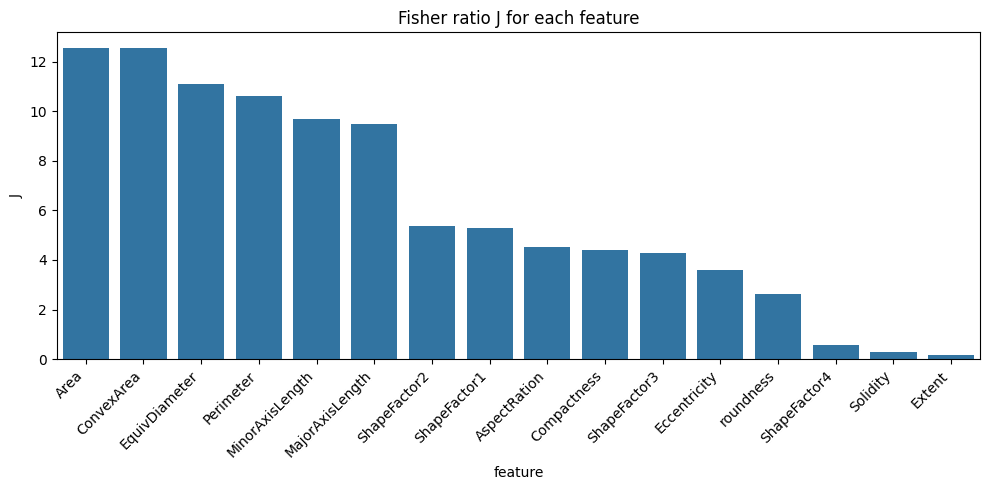

In [8]:
# Compute Fisher ratio J for each feature (multiclass extension)
# J_j = (sum_c n_c (mu_{cj} - mu_j)^2) / (sum_c n_c * sigma_{cj}^2)

X_train_arr = np.asarray(X_train_scaled)
y_train_arr = np.asarray(y_train)

classes, counts = np.unique(y_train_arr, return_counts=True)
C = len(classes)

n_samples, n_features = X_train_arr.shape

# Overall mean per feature
mu_overall = X_train_arr.mean(axis=0)

# Per-class means and variances per feature
mu_c = np.zeros((C, n_features))
var_c = np.zeros((C, n_features))

for idx, cls in enumerate(classes):
    X_c = X_train_arr[y_train_arr == cls]
    mu_c[idx] = X_c.mean(axis=0)
    var_c[idx] = X_c.var(axis=0, ddof=1)  # sample variance

# Between-class and within-class scatter per feature
n_c = counts.reshape(-1, 1)  # C x 1

# Between-class: sum_c n_c (mu_c - mu_overall)^2
Sb = (n_c * (mu_c - mu_overall) ** 2).sum(axis=0)

# Within-class: sum_c n_c * var_c
Sw = (n_c * var_c).sum(axis=0)

# Fisher ratio J for each feature (add epsilon to avoid division by zero)
eps = 1e-12
J = Sb / (Sw + eps)

# Map back to original feature names
feature_names = X_train.columns.tolist()

fisher_df = pd.DataFrame({
    'feature': feature_names,
    'J': J
}).sort_values('J', ascending=False).reset_index(drop=True)

print("Top features by Fisher ratio (most discriminative first):")
print(fisher_df)

# Optional: visualize
plt.figure(figsize=(10, 5))
sns.barplot(data=fisher_df, x='feature', y='J')
plt.xticks(rotation=45, ha='right')
plt.title('Fisher ratio J for each feature')
plt.tight_layout()
plt.show()

# Model

## Base

In [9]:
class Classification(ABC):
  @abstractmethod
  def fit(self, X: np.ndarray, y: np.ndarray) -> None:
    """
    Fit the model to the training data.
    """
    pass

  @abstractmethod
  def predict(self, X: np.ndarray) -> np.ndarray:
    """
    Predict the target values for the given input data.
    """
    pass

  def evaluate(self, y_hat: np.ndarray, y: np.ndarray) -> float:
    """
    Evaluate the model on the given input and target data.
    """
    pass

## Logistic Regression

In [10]:
class LogisticRegression(Classification):
    def __init__(
        self,
        solver: str | None = 'gradient_descent',
        learning_rate: float = LEARNING_RATE,
        max_iter: int = MAX_ITER,
    ):
        self.learning_rate = learning_rate
        self.max_iter = max_iter
        self.weights = None
        self.bias = None

    def _softmax(self, z):
        # Subtracting max(z) for numerical stability (prevents overflow)
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _one_hot(self, y, num_classes):
        return np.eye(num_classes)[y]

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        
        # Initialize Weights (Features x Classes) and Bias (1 x Classes)
        self.weights = np.zeros((n_features, n_classes))
        self.bias = np.zeros((1, n_classes))
        
        y_encoded = self._one_hot(y, n_classes)

        for i in range(self.max_iter):
            # Forward pass
            scores = np.dot(X, self.weights) + self.bias
            probs = self._softmax(scores)

            # Gradient calculation
            dw = (1 / n_samples) * np.dot(X.T, (probs - y_encoded))
            db = (1 / n_samples) * np.sum(probs - y_encoded, axis=0, keepdims=True)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            if i % 500 == 0:
                loss = -np.mean(np.sum(y_encoded * np.log(probs + 1e-15), axis=1))
                print(f"Iteration {i}: Loss {loss:.4f}")

    def predict(self, X: np.ndarray) -> np.ndarray:
        scores = np.dot(X, self.weights) + self.bias
        probs = self._softmax(scores)
        return np.argmax(probs, axis=1)

    def evaluate(self, y_hat: np.ndarray, y: np.ndarray) -> float:
        return np.mean(y_hat == y)

### Lapalace Approximation

## Linear Discriminant Analysis

In [11]:
class LDA(Classification):
    def __init__(self, reg: float = 1e-6):
        self.reg = reg
        self.classes_ = None
        self.priors_ = None
        self.means_ = None
        self.covariance_ = None
        self.inv_covariance_ = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape
        n_classes = len(self.classes_)

        self.priors_ = np.zeros(n_classes)
        self.means_ = np.zeros((n_classes, n_features))

        # Estimate class priors and class means
        for idx, cls in enumerate(self.classes_):
            X_cls = X[y == cls]
            self.priors_[idx] = X_cls.shape[0] / n_samples
            self.means_[idx] = np.mean(X_cls, axis=0)

        # Pooled covariance matrix (shared by all classes)
        covariance = np.zeros((n_features, n_features))
        for idx, cls in enumerate(self.classes_):
            X_cls = X[y == cls]
            centered = X_cls - self.means_[idx]
            covariance += centered.T @ centered

        covariance /= (n_samples - n_classes)

        # Small diagonal regularization for numerical stability
        covariance += self.reg * np.eye(n_features)

        self.covariance_ = covariance
        self.inv_covariance_ = np.linalg.inv(covariance)

    def _discriminant(self, X: np.ndarray, class_idx: int) -> np.ndarray:
        mu = self.means_[class_idx]
        prior = self.priors_[class_idx]

        # g_k(x) = x^T Sigma^-1 mu_k - 0.5 mu_k^T Sigma^-1 mu_k + log(pi_k)
        linear_term = X @ self.inv_covariance_ @ mu
        constant_term = -0.5 * (mu.T @ self.inv_covariance_ @ mu) + np.log(prior)
        return linear_term + constant_term

    def predict(self, X: np.ndarray) -> np.ndarray:
        scores = np.column_stack([
            self._discriminant(X, idx) for idx in range(len(self.classes_))
        ])
        return self.classes_[np.argmax(scores, axis=1)]

    def evaluate(self, y_hat: np.ndarray, y: np.ndarray) -> float:
        return np.mean(y_hat == y)

### 2D LDA projection and decision boundary

We now compute a 2D LDA subspace from the training data, project the samples into this space, and visualize both the projections and the LDA decision boundary.

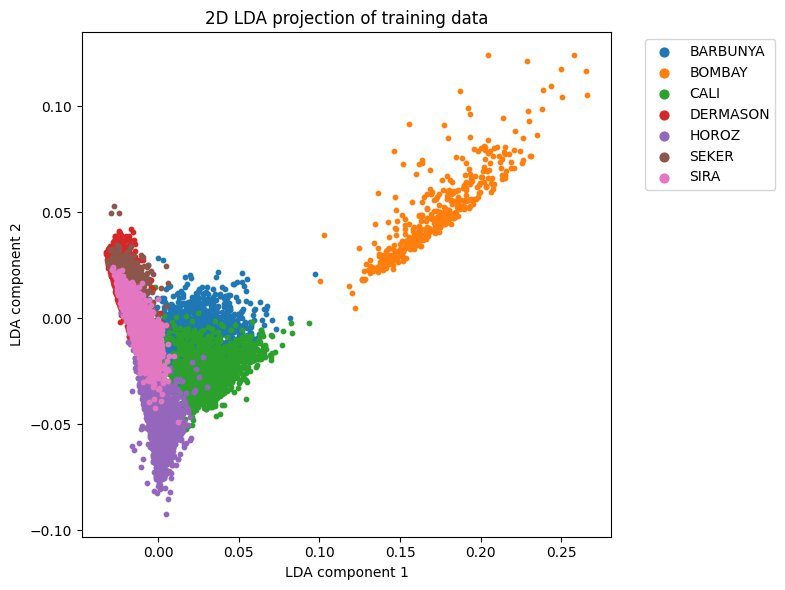

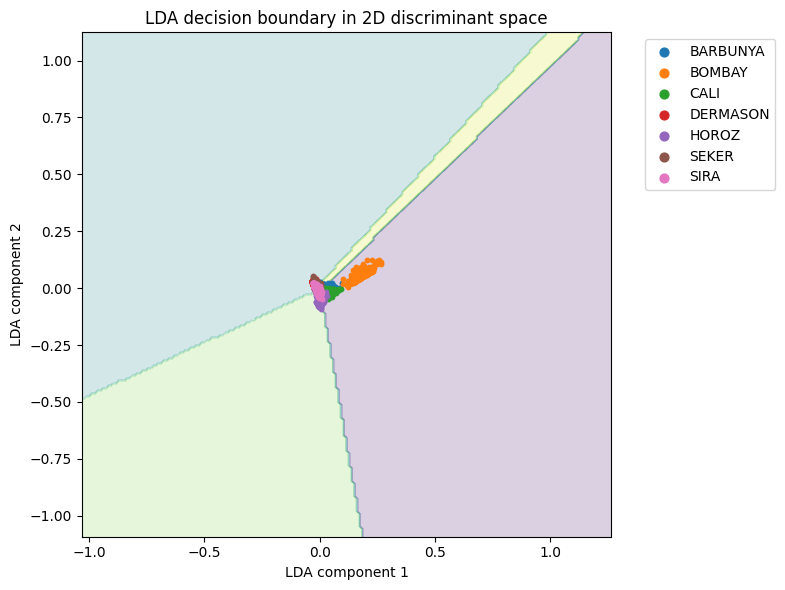

In [12]:
# Fit our LDA classifier on the original feature space
lda_model = LDA()
lda_model.fit(X_train_scaled, y_train)

# Compute LDA projection matrix W (top 2 discriminant directions)
X_train_arr = np.asarray(X_train_scaled)
y_train_arr = np.asarray(y_train)

classes, counts = np.unique(y_train_arr, return_counts=True)
C = len(classes)

n_samples, n_features = X_train_arr.shape

# Overall mean
mu_overall = X_train_arr.mean(axis=0)

# Within-class scatter Sw and between-class scatter Sb
Sw = np.zeros((n_features, n_features))
Sb = np.zeros((n_features, n_features))

for idx, cls in enumerate(classes):
    X_c = X_train_arr[y_train_arr == cls]
    n_c = X_c.shape[0]
    mu_c = X_c.mean(axis=0)
    centered = X_c - mu_c

    Sw += centered.T @ centered

    mean_diff = (mu_c - mu_overall).reshape(-1, 1)
    Sb += n_c * (mean_diff @ mean_diff.T)

# Solve generalized eigenproblem Sw^{-1} Sb
# Add small regularization to Sw for numerical stability
reg = 1e-6
Sw_reg = Sw + reg * np.eye(n_features)

# Compute matrix A = Sw^{-1} Sb
A = np.linalg.inv(Sw_reg) @ Sb

# Eigen-decomposition
eigvals, eigvecs = np.linalg.eig(A)

# Sort eigenvectors by eigenvalues in descending order
sorted_idx = np.argsort(eigvals)[::-1]
W = eigvecs[:, sorted_idx[:2]].real  # n_features x 2

# Project data into 2D LDA space
Z_train = (X_train_arr - mu_overall) @ W
Z_test = (X_test_scaled - mu_overall) @ W

# Plot 2D projection of training data
plt.figure(figsize=(8, 6))
for cls_idx, cls in enumerate(classes):
    mask = y_train_arr == cls
    plt.scatter(
        Z_train[mask, 0], Z_train[mask, 1],
        s=10,
        label=target_le.inverse_transform([cls])[0]
    )

plt.xlabel('LDA component 1')
plt.ylabel('LDA component 2')
plt.title('2D LDA projection of training data')
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Visualize LDA decision boundary in the 2D LDA space

# Create a grid over the 2D LDA space
x_min, x_max = Z_train[:, 0].min() - 1, Z_train[:, 0].max() + 1
y_min, y_max = Z_train[:, 1].min() - 1, Z_train[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Map grid points back to original (standardized) feature space
Z_grid = np.c_[xx.ravel(), yy.ravel()]
X_grid = Z_grid @ W.T + mu_overall  # approximate inverse mapping

# Predict class labels using our LDA classifier
Z_pred = lda_model.predict(X_grid)
Z_pred = Z_pred.reshape(xx.shape)

plt.figure(figsize=(8, 6))
# Plot decision regions
plt.contourf(xx, yy, Z_pred, alpha=0.2, levels=len(classes))

# Overlay training points
for cls_idx, cls in enumerate(classes):
    mask = y_train_arr == cls
    plt.scatter(
        Z_train[mask, 0], Z_train[mask, 1],
        s=10,
        label=target_le.inverse_transform([cls])[0]
    )

plt.xlabel('LDA component 1')
plt.ylabel('LDA component 2')
plt.title('LDA decision boundary in 2D discriminant space')
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Quadratic Discriminant Analysis

In [13]:
class QDA(Classification):
    def __init__(self, reg: float = 1e-6):
        self.reg = reg
        self.classes_ = None
        self.priors_ = None
        self.means_ = None
        self.covariances_ = None
        self.inv_covariances_ = None
        self.log_dets_ = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape
        n_classes = len(self.classes_)

        self.priors_ = np.zeros(n_classes)
        self.means_ = np.zeros((n_classes, n_features))
        self.covariances_ = []
        self.inv_covariances_ = []
        self.log_dets_ = np.zeros(n_classes)

        for idx, cls in enumerate(self.classes_):
            X_cls = X[y == cls]
            self.priors_[idx] = X_cls.shape[0] / n_samples
            self.means_[idx] = np.mean(X_cls, axis=0)

            centered = X_cls - self.means_[idx]
            cov = (centered.T @ centered) / (X_cls.shape[0] - 1)

            # Small diagonal regularization for numerical stability
            cov += self.reg * np.eye(n_features)

            self.covariances_.append(cov)
            self.inv_covariances_.append(np.linalg.inv(cov))
            sign, log_det = np.linalg.slogdet(cov)
            if sign <= 0:
                raise ValueError("Covariance matrix is not positive definite.")
            self.log_dets_[idx] = log_det

    def _discriminant(self, X: np.ndarray, class_idx: int) -> np.ndarray:
        mu = self.means_[class_idx]
        inv_cov = self.inv_covariances_[class_idx]
        log_det = self.log_dets_[class_idx]
        prior = self.priors_[class_idx]

        diff = X - mu
        quadratic_term = np.einsum("ij,jk,ik->i", diff, inv_cov, diff)

        # g_k(x) = -0.5*log|Sigma_k| - 0.5*(x-mu_k)^T Sigma_k^-1 (x-mu_k) + log(pi_k)
        return -0.5 * log_det - 0.5 * quadratic_term + np.log(prior)

    def predict(self, X: np.ndarray) -> np.ndarray:
        scores = np.column_stack([
            self._discriminant(X, idx) for idx in range(len(self.classes_))
        ])
        return self.classes_[np.argmax(scores, axis=1)]

    def evaluate(self, y_hat: np.ndarray, y: np.ndarray) -> float:
        return np.mean(y_hat == y)

# Evaluation

In [14]:
# 1. Initialize the model
model = LogisticRegression()

# 2. Fit the model on scaled training data
# X_train_scaled and y_train were created in the previous preprocessing step
model.fit(X_train_scaled, y_train)

# 3. Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# 4. Evaluate the performance
accuracy = model.evaluate(y_pred, y_test)

print(f"Model Accuracy: {accuracy * 100:.2f}%")

Iteration 0: Loss 1.9459
Iteration 500: Loss 0.7312
Iteration 1000: Loss 0.5625
Iteration 1500: Loss 0.4781
Iteration 2000: Loss 0.4268
Iteration 2500: Loss 0.3921
Iteration 3000: Loss 0.3671
Iteration 3500: Loss 0.3483
Iteration 4000: Loss 0.3336
Iteration 4500: Loss 0.3217
Iteration 5000: Loss 0.3120
Iteration 5500: Loss 0.3038
Iteration 6000: Loss 0.2969
Iteration 6500: Loss 0.2909
Iteration 7000: Loss 0.2857
Iteration 7500: Loss 0.2812
Iteration 8000: Loss 0.2772
Iteration 8500: Loss 0.2736
Iteration 9000: Loss 0.2703
Iteration 9500: Loss 0.2674
Model Accuracy: 92.25%


## Gaussian Naive Bayes (GNB) vs LDA

### Theory
Gaussian Naive Bayes (GNB) assumes conditional independence of features given the class:

$$
p(x \mid y=k) = \prod_{j=1}^d \mathcal{N}(x_j \mid \mu_{kj}, \sigma_{kj}^2)
$$

So each class effectively has a **diagonal** covariance matrix.

LDA instead assumes each class is Gaussian with its own mean but a **shared full covariance** $\Sigma$:

$$
p(x \mid y=k) = \mathcal{N}(x \mid \mu_k, \Sigma)
$$

So LDA can use correlations between features (off-diagonal terms), but it must estimate a single pooled $\Sigma$.

### When GNB can outperform LDA (despite independence)
GNB can be better when LDA’s extra modeling capacity (full shared covariance) becomes **too noisy** or **incorrect** for the data you have, e.g.:

1. Class-conditional covariances are close to diagonal (weak correlations), so the independence assumption is only mildly wrong.
2. The pooled covariance in LDA is ill-conditioned / hard to estimate reliably (common when dimensionality is high relative to effective samples per class).
3. Variances differ a lot across classes/features (GNB captures per-class diagonal variances; LDA ties them together through the shared pooled covariance).
4. Correlations are present but unstable/spurious due to limited samples; LDA may overfit correlation structure while GNB ignores it.

Empirically, we’ll check test accuracy for GNB/LDA/QDA and also compute a simple diagnostic: the **off-diagonal energy** of per-class covariances and the **condition number** of the pooled covariance used by LDA.

In [15]:
class GaussianNaiveBayes(Classification):
    def __init__(self, reg: float = 1e-9):
        self.reg = reg
        self.classes_ = None
        self.priors_ = None
        self.means_ = None
        self.vars_ = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape
        n_classes = len(self.classes_)

        self.priors_ = np.zeros(n_classes)
        self.means_ = np.zeros((n_classes, n_features))
        self.vars_ = np.zeros((n_classes, n_features))

        for idx, cls in enumerate(self.classes_):
            X_cls = X[y == cls]
            self.priors_[idx] = X_cls.shape[0] / n_samples
            self.means_[idx] = np.mean(X_cls, axis=0)
            # Sample variance per feature
            self.vars_[idx] = X_cls.var(axis=0, ddof=1)

        # Variance regularization to avoid divide-by-zero/log(0)
        self.vars_ += self.reg

    def predict(self, X: np.ndarray) -> np.ndarray:
        n_samples, n_features = X.shape
        n_classes = len(self.classes_)

        log_probs = np.zeros((n_samples, n_classes))
        const = -0.5 * n_features * np.log(2.0 * np.pi)

        for idx in range(n_classes):
            mu = self.means_[idx]
            var = self.vars_[idx]

            # log p(x|y=idx) under diagonal Gaussian
            diff2_over_var = (X - mu) ** 2 / var
            log_det = np.sum(np.log(var))

            log_likelihood = const - 0.5 * log_det - 0.5 * np.sum(diff2_over_var, axis=1)
            log_prior = np.log(self.priors_[idx])
            log_probs[:, idx] = log_prior + log_likelihood

        return self.classes_[np.argmax(log_probs, axis=1)]

    def evaluate(self, y_hat: np.ndarray, y: np.ndarray) -> float:
        return np.mean(y_hat == y)

In [16]:
# Empirical comparison: GNB vs LDA (and QDA)

gnb_model = GaussianNaiveBayes(reg=1e-9)
lda_model = LDA(reg=1e-6)
qda_model = QDA(reg=1e-6)

# Fit
for m in (gnb_model, lda_model, qda_model):
    m.fit(X_train_scaled, y_train)

# Predict
pred_gnb = gnb_model.predict(X_test_scaled)
pred_lda = lda_model.predict(X_test_scaled)
pred_qda = qda_model.predict(X_test_scaled)

# Evaluate
acc_gnb = gnb_model.evaluate(pred_gnb, y_test)
acc_lda = lda_model.evaluate(pred_lda, y_test)
acc_qda = qda_model.evaluate(pred_qda, y_test)

n_samples, d = X_train_scaled.shape
n_classes = len(np.unique(y_train))

print(f"Train n={n_samples}, d={d}, classes={n_classes}")
print(f"Accuracy: GNB={acc_gnb*100:.2f}% | LDA={acc_lda*100:.2f}% | QDA={acc_qda*100:.2f}%")

# Diagnostics: how close class covariances are to diagonal
X_train_arr = np.asarray(X_train_scaled)
y_train_arr = np.asarray(y_train)
classes, counts = np.unique(y_train_arr, return_counts=True)
C = len(classes)

offdiag_ratios = []

for idx, cls in enumerate(classes):
    X_c = X_train_arr[y_train_arr == cls]
    mu_c = X_c.mean(axis=0)
    centered = X_c - mu_c
    cov_c = centered.T @ centered / max(1, (X_c.shape[0] - 1))

    total_energy = np.sum(cov_c ** 2)
    diag_energy = np.sum(np.diag(cov_c) ** 2)
    off_energy_ratio = 0.0 if total_energy == 0 else (total_energy - diag_energy) / total_energy
    offdiag_ratios.append(off_energy_ratio)

avg_offdiag_ratio = float(np.mean(offdiag_ratios))

# Diagnostics: pooled covariance conditioning (what LDA inverts)
mu_overall = X_train_arr.mean(axis=0)
Sw = np.zeros((d, d))
for idx, cls in enumerate(classes):
    X_c = X_train_arr[y_train_arr == cls]
    mu_c = X_c.mean(axis=0)
    centered = X_c - mu_c
    Sw += centered.T @ centered

pooled = Sw / (n_samples - C)
pooled_reg = pooled + 1e-6 * np.eye(d)
cond_number = float(np.linalg.cond(pooled_reg))

print(f"Avg off-diagonal covariance energy ratio (per class): {avg_offdiag_ratio:.4f}")
print(f"Pooled covariance condition number (LDA): {cond_number:.2e}")

# Heuristic interpretation printed for convenience
if acc_gnb > acc_lda:
    print("\nGNB > LDA on this split. This is consistent when correlations are weak and/or LDA’s pooled covariance estimate is unstable.")
else:
    print("\nLDA >= GNB on this split. This is consistent when shared correlations/geometry help classification more than the variance reduction from diagonal assumptions.")

print("\nHeuristic note: smaller avg off-diagonal ratio -> GNB is more aligned with data; larger condition number -> LDA inversion/estimation is harder, which can let GNB win.")

Train n=10888, d=16, classes=7
Accuracy: GNB=90.38% | LDA=91.04% | QDA=91.55%
Avg off-diagonal covariance energy ratio (per class): 0.5536
Pooled covariance condition number (LDA): 5.27e+05

LDA >= GNB on this split. This is consistent when shared correlations/geometry help classification more than the variance reduction from diagonal assumptions.

Heuristic note: smaller avg off-diagonal ratio -> GNB is more aligned with data; larger condition number -> LDA inversion/estimation is harder, which can let GNB win.


## McNemar’s test (same test set)

For **multi-class** classification, each test sample still yields a **paired binary** outcome: each model is either correct or wrong on the true label. McNemar’s test uses only **discordant** pairs (one model right, the other wrong) to test whether the two models differ significantly in how often they are correct.

Run the cell below **after** the empirical comparison cell that defines `pred_gnb`, `pred_lda`, `pred_qda`, and `y_test`. It reports pairwise tests: GNB vs LDA, GNB vs QDA, and LDA vs QDA.

In [17]:
from scipy.stats import chi2, binomtest


def mcnemar_paired(y_true, y_pred_a, y_pred_b):
    """McNemar on paired correctness (any number of classes)."""
    correct_a = np.asarray(y_pred_a) == np.asarray(y_true)
    correct_b = np.asarray(y_pred_b) == np.asarray(y_true)
    n01 = int(np.sum(~correct_a & correct_b))
    n10 = int(np.sum(correct_a & ~correct_b))
    n_disc = n01 + n10
    if n_disc == 0:
        return {"n01": n01, "n10": n10, "statistic": np.nan, "pvalue": 1.0, "method": "exact"}
    if n_disc < 25:
        p = float(
            binomtest(min(n01, n10), n_disc, 0.5, alternative="two-sided").pvalue
        )
        return {"n01": n01, "n10": n10, "statistic": np.nan, "pvalue": p, "method": "exact"}
    stat = (abs(n01 - n10) - 1) ** 2 / n_disc
    p = float(1 - chi2.cdf(stat, df=1))
    return {"n01": n01, "n10": n10, "statistic": stat, "pvalue": p, "method": "chi2_cc"}


pairs = [
    ("GNB", "LDA", pred_gnb, pred_lda),
    ("GNB", "QDA", pred_gnb, pred_qda),
    ("LDA", "QDA", pred_lda, pred_qda),
]

alpha = 0.05
print("McNemar on Dry Bean test set (multiclass -> paired correct/incorrect per sample)\n")
for name_a, name_b, pa, pb in pairs:
    r = mcnemar_paired(y_test, pa, pb)
    sig = "reject H0 (significant difference)" if r["pvalue"] < alpha else "fail to reject H0"
    print(f"{name_a} vs {name_b}:")
    print(
        f"  discordant: n01={r['n01']} (only {name_b} correct), "
        f"n10={r['n10']} (only {name_a} correct)"
    )
    if not np.isnan(r["statistic"]):
        print(f"  chi2 (continuity-corrected) = {r['statistic']:.4f}")
    print(f"  p = {r['pvalue']:.4g} (two-sided, {r['method']})  alpha={alpha} -> {sig}\n")

McNemar on Dry Bean test set (multiclass -> paired correct/incorrect per sample)

GNB vs LDA:
  discordant: n01=83 (only LDA correct), n10=65 (only GNB correct)
  chi2 (continuity-corrected) = 1.9527
  p = 0.1623 (two-sided, chi2_cc)  alpha=0.05 -> fail to reject H0

GNB vs QDA:
  discordant: n01=81 (only QDA correct), n10=49 (only GNB correct)
  chi2 (continuity-corrected) = 7.3923
  p = 0.00655 (two-sided, chi2_cc)  alpha=0.05 -> reject H0 (significant difference)

LDA vs QDA:
  discordant: n01=50 (only QDA correct), n10=36 (only LDA correct)
  chi2 (continuity-corrected) = 1.9651
  p = 0.161 (two-sided, chi2_cc)  alpha=0.05 -> fail to reject H0



## Calibration analysis (Reliability diagram)

For multi-class classification, a simple way to draw a **reliability diagram** is to:

- For each test sample, take the model’s **predicted confidence** `c = max_k P(y=k | x)`.
- Group samples into bins of confidence.
- For each bin, plot **empirical accuracy** (fraction of samples where the predicted class is correct) vs **mean confidence**.

The code below generates this diagram for `GNB`, `LDA`, and `QDA` on the existing test set (`X_test_scaled`, `y_test`). It also reports **ECE** (Expected Calibration Error) for each model.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def softmax_logits(logits: np.ndarray) -> np.ndarray:
    """Stable softmax for logits -> probabilities."""
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / np.sum(exp, axis=1, keepdims=True)


def gnb_predict_proba(model: GaussianNaiveBayes, X: np.ndarray) -> np.ndarray:
    """Reconstruct class posterior probabilities for the custom GNB."""
    X = np.asarray(X)
    n_samples, d = X.shape
    n_classes = len(model.classes_)

    # log p(x | y=k) under diagonal Gaussians
    const = -0.5 * d * np.log(2.0 * np.pi)
    means = model.means_  # (C, d)
    vars_ = model.vars_  # (C, d)
    priors = model.priors_  # (C,)

    # diff^2 / var for all samples/classes: (N, C, d)
    diff2_over_var = (X[:, None, :] - means[None, :, :]) ** 2 / vars_[None, :, :]

    log_det = np.sum(np.log(vars_), axis=1)  # (C,)
    log_likelihood = const - 0.5 * log_det[None, :] - 0.5 * np.sum(diff2_over_var, axis=2)  # (N, C)
    log_prior = np.log(priors + 1e-300)[None, :]  # avoid log(0)

    log_post_unnorm = log_prior + log_likelihood
    return softmax_logits(log_post_unnorm)


def lda_predict_proba(model: LDA, X: np.ndarray) -> np.ndarray:
    """Reconstruct class posterior probabilities for the custom LDA."""
    X = np.asarray(X)
    C = len(model.classes_)
    scores = np.column_stack([model._discriminant(X, idx) for idx in range(C)])  # (N, C)
    return softmax_logits(scores)


def qda_predict_proba(model: QDA, X: np.ndarray) -> np.ndarray:
    """Reconstruct class posterior probabilities for the custom QDA."""
    X = np.asarray(X)
    C = len(model.classes_)
    scores = np.column_stack([model._discriminant(X, idx) for idx in range(C)])  # (N, C)
    return softmax_logits(scores)


def reliability_diagram_multiclass(y_true: np.ndarray, probs: np.ndarray, class_labels: np.ndarray, n_bins: int = 10):
    """Reliability diagram using max-confidence calibration."""
    y_true = np.asarray(y_true)
    probs = np.asarray(probs)

    conf = probs.max(axis=1)  # (N,)
    pred_idx = probs.argmax(axis=1)
    y_pred = class_labels[pred_idx]
    correct = (y_pred == y_true)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_counts = np.zeros(n_bins, dtype=int)
    bin_conf_mean = np.zeros(n_bins, dtype=float)
    bin_acc_mean = np.full(n_bins, np.nan, dtype=float)

    ece = 0.0
    N = len(y_true)

    for b in range(n_bins):
        left, right = bins[b], bins[b + 1]
        if b == n_bins - 1:
            mask = (conf >= left) & (conf <= right)
        else:
            mask = (conf >= left) & (conf < right)

        cnt = int(np.sum(mask))
        bin_counts[b] = cnt
        if cnt > 0:
            bin_conf_mean[b] = float(conf[mask].mean())
            bin_acc_mean[b] = float(correct[mask].mean())
            ece += (cnt / N) * abs(bin_acc_mean[b] - bin_conf_mean[b])

    return bins, bin_counts, bin_conf_mean, bin_acc_mean, ece


# --- Predicted probabilities ---
probs_gnb = gnb_predict_proba(gnb_model, X_test_scaled)
probs_lda = lda_predict_proba(lda_model, X_test_scaled)
probs_qda = qda_predict_proba(qda_model, X_test_scaled)

# --- Plot reliability diagrams ---
plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')

for name, probs, class_labels in [
    ('GNB', probs_gnb, gnb_model.classes_),
    ('LDA', probs_lda, lda_model.classes_),
    ('QDA', probs_qda, qda_model.classes_),
]:
    _, counts, conf_mean, acc_mean, ece = reliability_diagram_multiclass(
        y_true=y_test,
        probs=probs,
        class_labels=class_labels,
        n_bins=10,
    )
    mask = counts > 0
    plt.plot(conf_mean[mask], acc_mean[mask], marker='o', linewidth=1.5, label=f'{name} (ECE={ece:.3f})')

plt.xlabel('Mean predicted confidence')
plt.ylabel('Empirical accuracy')
plt.title('Multi-class calibration (confidence vs accuracy)')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Laplace approximation (Bayesian logistic regression)

We fit a **binary** logistic model with Gaussian prior on weights $w \sim \mathcal{N}(0, \lambda^{-1} I)$ so we can visualize the decision boundary in 2D (two classes, two features).

- **MAP**: minimize $-\log p(y|X,w) - \log p(w)$ using **IRLS** (Newton).
- **Hessian** of $-\log p(w|D)$ at MAP: $H = X^\top S X + \lambda I$ with $S_{ii} = \mu_i(1-\mu_i)$, $\mu_i = \sigma(w^\top \tilde{x}_i)$.
- **Laplace posterior**: $q(w) \approx \mathcal{N}(w_{\mathrm{MAP}}, H^{-1})$.

For $\tilde{x} = [1, x_1, x_2]^\top$, the logit $\eta = w^\top \tilde{x}$ has approximate posterior variance $\mathrm{Var}(\eta) \approx \tilde{x}^\top H^{-1} \tilde{x}$ (first-order in $w$ around the MAP).

We plot the **MAP** decision boundary ($\mathbb{E}[\eta]=0$) and the **±1σ** curves where $\mathbb{E}[\eta] = \pm \sqrt{\tilde{x}^\top H^{-1} \tilde{x}}$, i.e. the logit mean is one posterior standard deviation away from zero.

MAP weights [bias, w1, w2]: [-7.18672427  1.79503621  1.58798087]
Hessian H (neg log posterior) condition number: 122.64047224030244


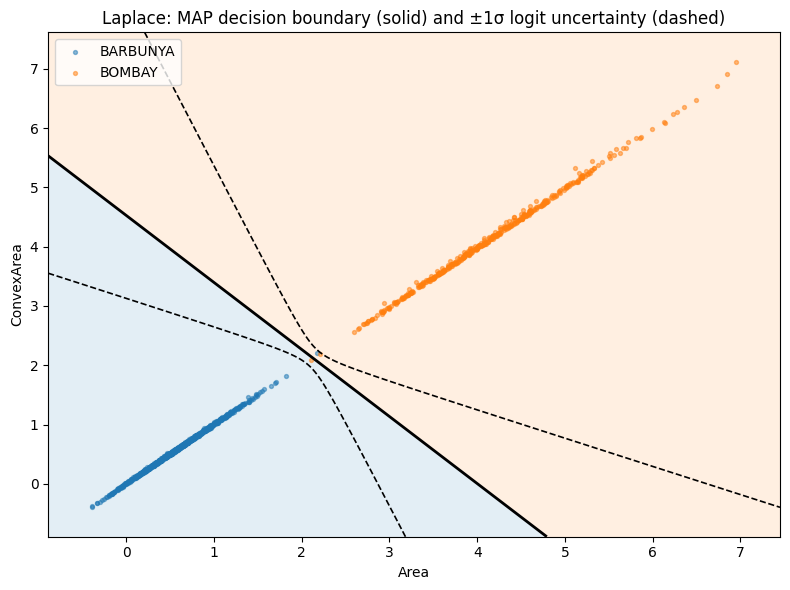

In [18]:
# Binary logistic regression: MAP (IRLS), Hessian at MAP, Laplace posterior, boundary ±1σ

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def irls_binary_logistic_map(X_design, y, prior_precision=1.0, max_iter=100, tol=1e-8):
    """
    X_design: (n, d) with intercept column first.
    y in {0,1}. Gaussian prior log p(w) = -prior_precision/2 ||w||^2.
    Returns w_map.
    """
    n, d = X_design.shape
    w = np.zeros(d)
    lam = prior_precision
    for _ in range(max_iter):
        p = sigmoid(X_design @ w)
        s = p * (1.0 - p)
        s = np.maximum(s, 1e-15)
        # Working response z_i = x_i^T w + (y_i - p_i) / s_i
        z = X_design @ w + (y - p) / s
        SX = X_design * s[:, np.newaxis]
        H = X_design.T @ SX + lam * np.eye(d)
        b = X_design.T @ (s * z)
        w_new = np.linalg.solve(H, b)
        if np.linalg.norm(w_new - w) < tol:
            w = w_new
            break
        w = w_new
    return w


def hessian_neg_log_posterior(X_design, w_map, prior_precision=1.0):
    """H = X^T S X + lambda I (Hessian of -log p(w|D) at MAP)."""
    p = sigmoid(X_design @ w_map)
    s = p * (1.0 - p)
    s = np.maximum(s, 1e-15)
    SX = X_design * s[:, np.newaxis]
    d = X_design.shape[1]
    return X_design.T @ SX + prior_precision * np.eye(d)


# --- Data: two classes, two features (2D plot) ---
class_a, class_b = 0, 1
mask = (y_train == class_a) | (y_train == class_b)
if mask.sum() < 20:
    raise RuntimeError("Not enough points for the chosen pair of classes.")

try:
    f0 = fisher_df.iloc[0]["feature"]
    f1 = fisher_df.iloc[1]["feature"]
    j0 = X_train.columns.get_loc(f0)
    j1 = X_train.columns.get_loc(f1)
except Exception:
    j0, j1 = 0, 1

X_bin = np.asarray(X_train_scaled[mask])[:, [j0, j1]]
y_bin = (np.asarray(y_train[mask]) == class_b).astype(np.float64)
n = X_bin.shape[0]
ones = np.ones((n, 1))
X_design = np.hstack([ones, X_bin])

prior_precision = 1.0
w_map = irls_binary_logistic_map(X_design, y_bin, prior_precision=prior_precision)
H = hessian_neg_log_posterior(X_design, w_map, prior_precision=prior_precision)
cov_w = np.linalg.inv(H)

print("MAP weights [bias, w1, w2]:", w_map)
print("Hessian H (neg log posterior) condition number:", np.linalg.cond(H))

# Grid for contours
x1_min, x1_max = X_bin[:, 0].min() - 0.5, X_bin[:, 0].max() + 0.5
x2_min, x2_max = X_bin[:, 1].min() - 0.5, X_bin[:, 1].max() + 0.5
gx1 = np.linspace(x1_min, x1_max, 200)
gx2 = np.linspace(x2_min, x2_max, 200)
G1, G2 = np.meshgrid(gx1, gx2)
T = G1.size
Xg = np.column_stack([np.ones(T), G1.ravel(), G2.ravel()])

mu_eta = Xg @ w_map
var_eta = np.einsum("ij,jk,ik->i", Xg, cov_w, Xg)
var_eta = np.maximum(var_eta, 1e-18)
sigma_eta = np.sqrt(var_eta)

Z0 = mu_eta.reshape(G1.shape)
Zp = (mu_eta - sigma_eta).reshape(G1.shape)
Zm = (mu_eta + sigma_eta).reshape(G1.shape)

feat_names = [X_train.columns[j0], X_train.columns[j1]]
plt.figure(figsize=(8, 6))
z_lo = float(min(Z0.min(), -1.0))
z_hi = float(max(Z0.max(), 1.0))
plt.contourf(G1, G2, Z0, levels=[z_lo, 0.0, z_hi], alpha=0.12, colors=["C0", "C1"])
plt.contour(G1, G2, Z0, levels=[0], colors="k", linewidths=2, linestyles="-")
plt.contour(G1, G2, Zp, levels=[0], colors="k", linewidths=1.2, linestyles="--")
plt.contour(G1, G2, Zm, levels=[0], colors="k", linewidths=1.2, linestyles="--")
plt.scatter(X_bin[y_bin == 0, 0], X_bin[y_bin == 0, 1], s=8, alpha=0.5, label=target_le.inverse_transform([class_a])[0])
plt.scatter(X_bin[y_bin == 1, 0], X_bin[y_bin == 1, 1], s=8, alpha=0.5, label=target_le.inverse_transform([class_b])[0])
plt.xlabel(feat_names[0])
plt.ylabel(feat_names[1])
plt.title("Laplace: MAP decision boundary (solid) and ±1σ logit uncertainty (dashed)")
plt.legend()
plt.tight_layout()
plt.show()